# Stage B: supervised контрастивное обучение на парафразах

Обучаем **три модели** методом InfoNCE на парафразах с тремя источниками негативов.

## Источники данных

### Positive pairs
* `merionum/ru_paraphraser` `class==1` — настоящие парафразы (~1.8k пар) — для всех трёх моделей.
* `deepvk/ru-HNP` (query, pos) — только для **mE5-instruct** и **Qwen3-Emb-0.6B**. Для `USER-bge-m3` пропускаем: модель уже обучалась на этом датасете.

### Negatives (три типа одновременно)
1. **Mined hard negatives** (ANCE-style) — top-k ближайших по cos `text_2` чужих якорей. **Защита от дублей**: глобальный обратный индекс `text → set(positions)` маскирует все вхождения текста, который встречается в нескольких парах (фикс кейса `id_2=4146` из `ru_paraphraser`).
2. **Explicit negatives из `ru_paraphraser` class = -1** — точно НЕ парафразы, по тем же якорям.
3. **HNP negatives** — `neg` поле из `ru-HNP` (для соответствующих positive pairs).
4. **In-batch negatives** — все остальные positives в батче (бесплатно, через симметричный InfoNCE).

## Что важно

* Обучение идёт **с frozen base** — это чистый Stage B (не поверх Stage C).
* **DoRA включён** (`use_dora=True`).
* **Gradient Cache** позволяет держать виртуальный батч 128 при чанке 16 (или 32/4 для Qwen3) — много in-batch negatives для InfoNCE.
* **Early stopping** по `val_stsb` с patience=2; перед следующей эпохой восстанавливается лучший снэпшот.
* На выходе — три файла `./checkpoints_stageB/{model}__stageB.pt`. Их можно подать на вход в Stage-C ноутбук как стартовую точку (вместо frozen-base LoRA-инициализации).

In [ ]:
# !pip uninstall -y torch torchvision torchaudio torchao
# !pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cu121
# !pip install -U "transformers>=4.40" "datasets>=2.18" "peft==0.12.0" "accelerate" "scipy" "tqdm"

In [ ]:
import os, math, random, json, gc as _gc
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, get_peft_model_state_dict, set_peft_model_state_dict
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ----- Конфигурация -----
USE_DORA       = True
CKPT_DIR       = "./checkpoints_stageB"
HISTORY_DIR    = "./histories_stageB"
os.makedirs(CKPT_DIR, exist_ok=True); os.makedirs(HISTORY_DIR, exist_ok=True)

print(f"USE_DORA={USE_DORA}; ckpts -> {CKPT_DIR}")


Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
USE_DORA=True; ckpts -> ./checkpoints_stageB


In [ ]:
# ----- Eval-датасеты (только eval, train STS не используем — Stage B не на STS) -----
def sts_quality(y_true, y_pred):
    p = pearsonr(y_true, y_pred)[0]
    s = spearmanr(y_true, y_pred)[0]
    return float((p + s) / 2.0)

stsb  = load_dataset("PhilipMay/stsb_multi_mt", "ru")
sts22 = load_dataset("mteb/sts22-crosslingual-sts", "ru")

def _prep(ds, s1c="sentence1", s2c="sentence2", yc="similarity_score"):
    s1 = [x[s1c] for x in ds]; s2 = [x[s2c] for x in ds]
    y  = np.array([float(x[yc]) for x in ds], dtype=np.float32)
    return s1, s2, y

val_s1,  val_s2,  val_y                     = _prep(stsb["dev"])
test_s1, test_s2, test_y                    = _prep(stsb["test"])
sts22_test_s1, sts22_test_s2, sts22_test_y  = _prep(sts22["test"], "sentence1", "sentence2", "score")
print(f"STSB dev={len(val_s1)}, test={len(test_s1)}; STS22 test={len(sts22_test_s1)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ru/train-00000-of-00001.parquet:   0%|          | 0.00/721k [00:00<?, ?B/s]

ru/test-00000-of-00001.parquet:   0%|          | 0.00/158k [00:00<?, ?B/s]

ru/dev-00000-of-00001.parquet:   0%|          | 0.00/209k [00:00<?, ?B/s]

...

Generating dev split:   0%|          | 0/1500 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

test/ru.jsonl.gz:   0%|          | 0.00/496k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/265 [00:00<?, ? examples/s]

STSB dev=1500, test=1379; STS22 test=265


In [ ]:
# ----- ru_paraphraser: positives (class==1) + explicit negatives (class=1}) -----
par = load_dataset("merionum/ru_paraphraser", trust_remote_code=True)
def _cls(ex):
    c = ex.get("class")
    try: return int(c)
    except Exception:
        try: return int(str(c).strip())
        except Exception: return None

par_tr = par["train"]
par_pos_pairs = [(ex["text_1"], ex["text_2"]) for ex in par_tr if _cls(ex) == 1]
par_neg_pairs = [(ex["text_1"], ex["text_2"]) for ex in par_tr if _cls(ex) == -1]
print(f"ru_paraphraser positives (class=1): {len(par_pos_pairs)}")
print(f"ru_paraphraser explicit negatives (class=-1): {len(par_neg_pairs)}")

par_a = [a for a, b in par_pos_pairs]
par_b = [b for a, b in par_pos_pairs]

# --- safe-mining индекс: текст -> множество позиций, где он играет positive-роль ---
def _norm(t): return t.strip().lower()

text_to_pos_indices: Dict[str, set] = {}
for i, (a, b) in enumerate(par_pos_pairs):
    text_to_pos_indices.setdefault(_norm(a), set()).add(i)
    text_to_pos_indices.setdefault(_norm(b), set()).add(i)

# --- explicit negs by anchor (берём для каждого якоря его текстовых негативов) ---
explicit_neg_for: Dict[str, List[str]] = {}
for (a, b) in par_neg_pairs:
    explicit_neg_for.setdefault(_norm(a), []).append(b)
    explicit_neg_for.setdefault(_norm(b), []).append(a)

n_with_expl = sum(1 for a in par_a if _norm(a) in explicit_neg_for)
print(f"  positives with at least one explicit negative: {n_with_expl}/{len(par_a)}")


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'merionum/ru_paraphraser' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'merionum/ru_paraphraser' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/7227 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1924 [00:00<?, ? examples/s]

ru_paraphraser positives (class=1): 1688
ru_paraphraser explicit negatives (class=-1): 2582
  positives with at least one explicit negative: 115/1688


In [ ]:
# ----- ru-HNP triplets (для mE5-instruct и Qwen3, НЕ для USER-bge-m3) -----
USE_HNP_FOR = {"mE5-instruct", "Qwen3-Emb-8B"}    # USER-bge-m3 уже тренировался на ru-HNP

try:
    hnp = load_dataset("deepvk/ru-HNP")
    hnp_tr = hnp["train"].shuffle(seed=SEED).select(range(min(HNP_MAX_ROWS, len(hnp["train"]))))

    def _first(x):
        if x is None: return None
        if isinstance(x, list): return x[0] if x else None
        if isinstance(x, str):  return x
        return None

    hnp_q, hnp_p, hnp_n = [], [], []
    for ex in hnp_tr:
        q = ex.get("query"); p = _first(ex.get("pos")); n = _first(ex.get("neg"))
        if q and p and n and len(q.strip()) >= 5 and len(p.strip()) >= 5 and len(n.strip()) >= 5:
            hnp_q.append(q); hnp_p.append(p); hnp_n.append(n)
    print(f"ru-HNP filtered triplets: {len(hnp_q)}")
except Exception as e:
    print(f"!! ru-HNP not loaded ({e}). Stage B will run without it for {USE_HNP_FOR}.")
    hnp_q, hnp_p, hnp_n = [], [], []


README.md: 0.00B [00:00, ?B/s]

train.parquet:   0%|          | 0.00/86.9M [00:00<?, ?B/s]

val.parquet:   0%|          | 0.00/538k [00:00<?, ?B/s]

test.parquet:   0%|          | 0.00/1.78M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/590 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

ru-HNP filtered triplets: 1000


In [ ]:
# ----- Gradient Cache c поддержкой явных hard negatives -----
class GradientCache:
    def __init__(self, model, optimizer, chunk_size=16, temperature=0.05):
        self.model = model
        self.optimizer = optimizer
        self.chunk_size = chunk_size
        self.temperature = temperature

    @torch.no_grad()
    def _encode_no_grad(self, texts):
        parts = []
        for i in range(0, len(texts), self.chunk_size):
            parts.append(self.model(texts[i:i+self.chunk_size]).detach())
        return torch.cat(parts, 0)

    def step(self, texts_a, texts_b, hard_neg_texts=None):
        was = self.model.training
        self.model.eval()
        q_full = self._encode_no_grad(texts_a)
        p_full = self._encode_no_grad(texts_b)
        n_full = self._encode_no_grad(hard_neg_texts) if hard_neg_texts else None
        self.model.train(was)

        q = q_full.detach().requires_grad_(True)
        p = p_full.detach().requires_grad_(True)
        if n_full is not None:
            n = n_full.detach().requires_grad_(True)
            bank = torch.cat([p, n], 0)
        else:
            n = None; bank = p

        logits = (q @ bank.T) / self.temperature
        labels = torch.arange(q.size(0), device=q.device)
        loss_fwd = F.cross_entropy(logits, labels)
        loss_bwd = F.cross_entropy((p @ q.T) / self.temperature, labels)
        loss = 0.5 * (loss_fwd + loss_bwd)
        loss.backward()
        q_grad = q.grad.detach(); p_grad = p.grad.detach()
        n_grad = n.grad.detach() if n is not None else None
        loss_value = loss.item()
        del q, p, n, bank, logits, loss

        self.optimizer.zero_grad(set_to_none=True)
        for i in range(0, len(texts_a), self.chunk_size):
            qc = self.model(texts_a[i:i+self.chunk_size])
            pc = self.model(texts_b[i:i+self.chunk_size])
            sg = (qc * q_grad[i:i+self.chunk_size]).sum() + (pc * p_grad[i:i+self.chunk_size]).sum()
            sg.backward()
            del qc, pc, sg
        if hard_neg_texts:
            for i in range(0, len(hard_neg_texts), self.chunk_size):
                nc = self.model(hard_neg_texts[i:i+self.chunk_size])
                sg = (nc * n_grad[i:i+self.chunk_size]).sum()
                sg.backward()
                del nc, sg

        self.optimizer.step()
        self.optimizer.zero_grad(set_to_none=True)
        return loss_value


In [ ]:
# ----- STSEncoder (тот же что в Stage-A/C ноутбуках) -----
def _detect_lora_targets(model) -> List[str]:
    names = {n for n, _ in model.named_modules()}
    if any(".q_proj" in n for n in names):
        return ["q_proj", "k_proj", "v_proj", "o_proj"]
    return ["query", "key", "value", "output.dense"]

def last_token_pool(h, attention_mask):
    left_padding = (attention_mask[:, -1].sum() == attention_mask.shape[0])
    if left_padding:
        return h[:, -1]
    seq_lens = attention_mask.sum(dim=1) - 1
    bs = h.size(0)
    return h[torch.arange(bs, device=h.device), seq_lens]

E5_INSTRUCT_TASK = "Given a text, retrieve relevant passages"

# QWEN_INSTRUCT_TASK = "Retrieve semantically similar text"

QWEN_INSTRUCT_TASK = "Given a text, retrieve relevant passages"

@dataclass
class ModelSpec:
    name: str
    model_id: str
    pooling: str
    prompt: str
    is_qwen: bool = False
    dtype: torch.dtype = torch.float32
    max_length: int = 192
    lora_r: int = 16
    lora_alpha: int = 32
    lora_dropout: float = 0.1


class STSEncoder(nn.Module):
    def __init__(self, spec: ModelSpec, mode: str = "lora", use_dora: bool = True):
        super().__init__()
        self.spec = spec
        self.tokenizer = AutoTokenizer.from_pretrained(
            spec.model_id, use_fast=True,
            padding_side="left" if spec.is_qwen else "right",
            trust_remote_code=True,
        )
        kw = {"trust_remote_code": True}
        if spec.dtype != torch.float32:
            kw["torch_dtype"] = spec.dtype
        base = AutoModel.from_pretrained(spec.model_id, **kw)

        if mode == "lora":
            targets = _detect_lora_targets(base)
            cfg_kwargs = dict(r=spec.lora_r, lora_alpha=spec.lora_alpha,
                              lora_dropout=spec.lora_dropout, bias="none",
                              target_modules=targets,
                              task_type=TaskType.FEATURE_EXTRACTION)
            if use_dora:
                try:
                    cfg = LoraConfig(**cfg_kwargs, use_dora=True)
                except TypeError:
                    cfg = LoraConfig(**cfg_kwargs)
                    print(f"  [warn] DoRA not supported, falling back to LoRA")
            else:
                cfg = LoraConfig(**cfg_kwargs)
            self.model = get_peft_model(base, cfg)
        elif mode == "frozen":
            self.model = base
            for p in self.model.parameters(): p.requires_grad = False
        else:
            self.model = base

    def trainable_params(self):
        n_tr  = sum(p.numel() for p in self.model.parameters() if p.requires_grad)
        n_tot = sum(p.numel() for p in self.model.parameters())
        return n_tr, n_tot

    def _prep(self, texts):
        if self.spec.prompt == "e5_instruct":
            return [f"Instruct: {E5_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        elif self.spec.prompt == "qwen_instruct":
            return [f"Instruct: {QWEN_INSTRUCT_TASK}\nQuery: {t}" for t in texts]
        return list(texts)

    def forward(self, texts):
        texts = self._prep(texts)
        tok = self.tokenizer(texts, padding=True, truncation=True,
                             max_length=self.spec.max_length, return_tensors="pt").to(device)
        out = self.model(**tok)
        h = out.last_hidden_state
        if self.spec.pooling == "cls":
            emb = h[:, 0]
        elif self.spec.pooling == "last":
            emb = last_token_pool(h, tok["attention_mask"])
        else:
            attn = tok["attention_mask"].unsqueeze(-1).float()
            emb  = (h * attn).sum(1) / attn.sum(1).clamp(min=1e-6)
        return F.normalize(emb.float(), p=2, dim=-1)

    @torch.no_grad()
    def encode(self, texts, batch_size: int = 64, to_cpu: bool = True):
        was = self.training; self.eval()
        embs = []
        for i in range(0, len(texts), batch_size):
            e = self.forward(texts[i:i+batch_size]).detach()
            embs.append(e.cpu() if to_cpu else e)
        self.train(was)
        return torch.cat(embs, 0)

# --- snapshot/restore + ckpt I/O ---
def snap(model: STSEncoder):
    sd = get_peft_model_state_dict(model.model)
    return {k: v.detach().clone().cpu() for k, v in sd.items()}

def restore(model: STSEncoder, snapshot):
    set_peft_model_state_dict(model.model, {k: v.to(device) for k, v in snapshot.items()})


In [ ]:
# ----- Eval helpers + EarlyStopper -----
@torch.no_grad()
def eval_sts(model, s1, s2, y, batch_size=64):
    e1 = model.encode(s1, batch_size=batch_size)
    e2 = model.encode(s2, batch_size=batch_size)
    return sts_quality(y, (e1 * e2).sum(-1).numpy())

def full_eval(model, batch_size=64):
    return {
        "val_stsb":   eval_sts(model, val_s1,  val_s2,  val_y, batch_size),
        "test_stsb":  eval_sts(model, test_s1, test_s2, test_y, batch_size),
        "test_sts22": eval_sts(model, sts22_test_s1, sts22_test_s2, sts22_test_y, batch_size),
    }

class EarlyStopper:
    def __init__(self, patience=2, min_delta=1e-4):
        self.patience = patience; self.min_delta = min_delta
        self.best = -1.0; self.best_epoch = -1; self.best_snap = None; self.cnt = 0
    def update(self, model, ep, val):
        if val > self.best + self.min_delta:
            self.best = val; self.best_epoch = ep
            self.best_snap = snap(model); self.cnt = 0
            return False
        self.cnt += 1
        return self.cnt >= self.patience


In [ ]:
# ----- Safe ANCE-style hard negative mining (с защитой от дублей) -----
def safe_mine_hard_negatives(model, anchors_a, anchors_b, k=2, batch_chunk=64):
    # Маскирует все индексы j, где anchors_a[j] или anchors_b[j] совпадает по нормированному
    # тексту с anchors_a[i] или anchors_b[i]. Это исключает кейс
    # "разные якоря, тот же positive" (пример id_2=4146 из ru_paraphraser).
    emb_a = model.encode(anchors_a, batch_size=batch_chunk, to_cpu=True)
    emb_b = model.encode(anchors_b, batch_size=batch_chunk, to_cpu=True)
    N = emb_a.size(0)

    pos_of_text: Dict[str, set] = {}
    for j, (a, b) in enumerate(zip(anchors_a, anchors_b)):
        pos_of_text.setdefault(_norm(a), set()).add(j)
        pos_of_text.setdefault(_norm(b), set()).add(j)

    topk = torch.zeros(N, k, dtype=torch.long)
    for i_start in range(0, N, 1024):
        i_end = min(i_start + 1024, N)
        sims = emb_a[i_start:i_end] @ emb_b.T               # [bs, N]
        for li, gi in enumerate(range(i_start, i_end)):
            forbid = pos_of_text.get(_norm(anchors_a[gi]), set()) \
                   | pos_of_text.get(_norm(anchors_b[gi]), set())
            for j in forbid:
                if 0 <= j < N:
                    sims[li, j] = -1e9
        _, idx = sims.topk(k, dim=1)
        topk[i_start:i_end] = idx
    return topk.numpy()

def _build_explicit_negs_for_anchor(anchor_text, k):
    pool = explicit_neg_for.get(_norm(anchor_text), [])
    if not pool: return []
    if len(pool) >= k: return random.sample(pool, k)
    return pool + random.choices(pool, k=k - len(pool))


In [ ]:
# ----- Training loop Stage B -----
def train_stage_b(model: STSEncoder, anchors_a, anchors_b, *,
                  hnp_query=None, hnp_pos=None, hnp_neg=None,
                  max_epochs=8, batch_size=128, chunk_size=16,
                  lr=2e-5, weight_decay=1e-2, temperature=0.05, warmup_ratio=0.1,
                  patience=2,
                  hard_k_mined=2, hard_k_explicit=2, hard_k_hnp=1,
                  eval_bs=64, tag="run"):
    # Объединяем источники positive pairs
    A_list = list(anchors_a); B_list = list(anchors_b)
    has_hnp = hnp_query is not None and len(hnp_query) > 0
    n_par = len(A_list)
    if has_hnp:
        A_list += list(hnp_query); B_list += list(hnp_pos)
    n_total = len(A_list)
    print(f"[{tag}] total positive pairs: {n_total} (par={n_par}"
          + (f", hnp={len(hnp_query)}" if has_hnp else "") + ")")

    params = [p for p in model.parameters() if p.requires_grad]
    optim  = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    steps_per_epoch = max(1, n_total // batch_size)
    total_steps = steps_per_epoch * max_epochs
    sched = get_cosine_schedule_with_warmup(optim, int(total_steps * warmup_ratio), total_steps)
    cache = GradientCache(model, optim, chunk_size=chunk_size, temperature=temperature)
    stopper = EarlyStopper(patience=patience)

    history = []
    base = full_eval(model, batch_size=eval_bs)
    base.update(epoch=0, loss=float("nan"))
    history.append(base)
    print(f"[{tag}] baseline (frozen): val={base['val_stsb']:.4f} "
          f"test_stsb={base['test_stsb']:.4f} test_sts22={base['test_sts22']:.4f}")

    hn_idx = None
    for ep in range(1, max_epochs + 1):
        # --- ANCE refresh: пересчитываем hard negatives перед каждой эпохой ---
        if hard_k_mined > 0:
            print(f"[{tag}] mining hard negatives (k={hard_k_mined}) on {n_par} paraphrase pairs...")
            hn_idx = safe_mine_hard_negatives(model, anchors_a, anchors_b,
                                              k=hard_k_mined, batch_chunk=eval_bs)

        model.train()
        losses = []
        idx = np.random.permutation(n_total)
        pbar = tqdm(range(0, n_total, batch_size),
                    desc=f"[{tag}] StageB ep {ep}/{max_epochs}", leave=False)
        for i in pbar:
            sub = idx[i:i+batch_size]
            if len(sub) < 2: continue
            a_batch = [A_list[j] for j in sub]
            b_batch = [B_list[j] for j in sub]

            # Собираем плоский список hard negatives
            hard_texts = []
            for j in sub:
                # 1) mined hard negs — только для par-пар (j < n_par)
                if hard_k_mined > 0 and j < n_par and hn_idx is not None:
                    for neg_j in hn_idx[j][:hard_k_mined]:
                        hard_texts.append(anchors_b[int(neg_j)])
                # 2) explicit negs из class=-1
                if hard_k_explicit > 0:
                    expl = _build_explicit_negs_for_anchor(A_list[j], hard_k_explicit)
                    if expl:
                        hard_texts.extend(expl)
                    elif hard_k_mined > 0 and j < n_par and hn_idx is not None:
                        # нет явного — добираем майнингом
                        extra = [anchors_b[int(nj)]
                                 for nj in hn_idx[j][hard_k_mined:hard_k_mined+hard_k_explicit]]
                        hard_texts.extend(extra)
                # 3) HNP negative для HNP-пары
                if has_hnp and hard_k_hnp > 0 and j >= n_par:
                    hard_texts.append(hnp_neg[j - n_par])

            loss = cache.step(a_batch, b_batch,
                              hard_neg_texts=hard_texts if hard_texts else None)
            sched.step(); losses.append(loss)
            pbar.set_postfix(loss=f"{np.mean(losses):.4f}")

        m = full_eval(model, batch_size=eval_bs)
        m.update(epoch=ep, loss=float(np.mean(losses)) if losses else float("nan"))
        history.append(m)
        print(f"[{tag}] ep {ep}: loss={m['loss']:.4f} val={m['val_stsb']:.4f} "
              f"test_stsb={m['test_stsb']:.4f} test_sts22={m['test_sts22']:.4f}")

        if stopper.update(model, ep, m["val_stsb"]):
            print(f"[{tag}] early stop @ ep {ep} (best val={stopper.best:.4f} @ ep {stopper.best_epoch})")
            break

    if stopper.best_snap is not None:
        restore(model, stopper.best_snap)
        print(f"[{tag}] restored best-val (val={stopper.best:.4f} @ ep {stopper.best_epoch})")
    return history, stopper


In [ ]:
# ----- Конфиги моделей и параметры обучения Stage B -----
MODEL_SPECS = {
    "USER-bge-m3": ModelSpec(
        name="USER-bge-m3", model_id="deepvk/USER-bge-m3",
        pooling="cls", prompt="none",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "mE5-instruct": ModelSpec(
        name="mE5-instruct", model_id="intfloat/multilingual-e5-large-instruct",
        pooling="mean", prompt="e5_instruct",
        is_qwen=False, dtype=torch.float32, max_length=192,
        lora_r=16, lora_alpha=32, lora_dropout=0.1,
    ),
    "Qwen3-Emb-8B": ModelSpec(
        name="Qwen3-Emb-4B", model_id="Qwen/Qwen3-Embedding-4B",
        pooling="last", prompt="qwen_instruct",
        is_qwen=True, dtype=torch.bfloat16, max_length=256,
        lora_r=16, lora_alpha=32, lora_dropout=0.05,
    ),
}

# По модели: батчи и LR. Qwen3 любит более высокий LR на LoRA (1e-4) и меньший батч.
TRAIN_KW = {
    "USER-bge-m3":   dict(max_epochs=4, batch_size=128, chunk_size=16, lr=2e-5,
                          temperature=0.05, patience=4,
                          hard_k_mined=2, hard_k_explicit=3, hard_k_hnp=0,  # USER-bge-m3 без HNP
                          eval_bs=64),
    "mE5-instruct":  dict(max_epochs=4, batch_size=96,  chunk_size=12, lr=2e-5,
                          temperature=0.05, patience=4,
                          hard_k_mined=2, hard_k_explicit=2, hard_k_hnp=2,
                          eval_bs=64),
    "Qwen3-Emb-8B":dict(max_epochs=4, batch_size=32,  chunk_size=4,  lr=1e-4,
                          temperature=0.05, patience=4,
                          hard_k_mined=2, hard_k_explicit=2, hard_k_hnp=2,
                          eval_bs=24),
}

def free_gpu():
    _gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache(); torch.cuda.synchronize()


In [ ]:
# ----- Baselines (frozen, без обучения) — нужны для измерения дельты Stage B -----
BASELINES = {}
for name, spec in MODEL_SPECS.items():
    print(f"\n=== Baseline: {name} ===")
    try:
        m = STSEncoder(spec, mode="frozen", use_dora=False).to(device)
        eval_bs = TRAIN_KW[name]["eval_bs"]
        BASELINES[name] = full_eval(m, batch_size=eval_bs)
        print(f"  val={BASELINES[name]['val_stsb']:.4f}  "
              f"test_stsb={BASELINES[name]['test_stsb']:.4f}  "
              f"test_sts22={BASELINES[name]['test_sts22']:.4f}")
        del m; free_gpu()
    except Exception as e:
        print(f"  !! {name} failed: {type(e).__name__}: {e}")
        BASELINES[name] = {"val_stsb": float("nan"), "test_stsb": float("nan"), "test_sts22": float("nan")}
        free_gpu()

pd.DataFrame(BASELINES).T



=== Baseline: USER-bge-m3 ===


config.json:   0%|          | 0.00/697 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  val=0.8655  test_stsb=0.8512  test_sts22=0.6800


,val_stsb,test_stsb,test_sts22
USER-bge-m3,0.857217,0.828224,0.676297
mE5-instruct,0.872453,0.843576,0.661550
Qwen3-Emb-8B,0.865456,0.851154,0.680027


In [ ]:
# ----- Главный прогон: обучение трёх моделей Stage B и сохранение чекпойнтов -----
RESULTS: Dict[str, Dict] = {}
HISTORIES: Dict[str, List[Dict]] = {}
CKPT_PATHS: Dict[str, str] = {}

for model_name, spec in MODEL_SPECS.items():
    print(f"\n{'#'*70}\n# Stage B :: {model_name}\n{'#'*70}")
    try:
        m = STSEncoder(spec, mode="lora", use_dora=USE_DORA).to(device)
        n_tr, n_tot = m.trainable_params()
        print(f"  LoRA{'(+DoRA)' if USE_DORA else ''}: {n_tr/1e6:.2f}M / {n_tot/1e6:.1f}M trainable")

        # Передавать ru-HNP только моделям из USE_HNP_FOR
        kw = dict(TRAIN_KW[model_name])
        if model_name in USE_HNP_FOR and len(hnp_q) > 0:
            kw["hnp_query"], kw["hnp_pos"], kw["hnp_neg"] = hnp_q, hnp_p, hnp_n
        else:
            kw["hnp_query"], kw["hnp_pos"], kw["hnp_neg"] = None, None, None
            kw["hard_k_hnp"] = 0
            if model_name in USE_HNP_FOR:
                print(f"  [info] {model_name} would use ru-HNP, but it's empty/unloaded")
            else:
                print(f"  [info] {model_name}: skipping ru-HNP (already trained on it)")

        history, stopper = train_stage_b(m, par_a, par_b, tag=model_name, **kw)
        HISTORIES[model_name] = history

        # Финальная оценка (после restore лучшего снэпшота)
        end_metrics = full_eval(m, batch_size=kw["eval_bs"])
        base = BASELINES[model_name]
        RESULTS[model_name] = {
            "baseline":   base,
            "end":        end_metrics,
            "delta_val":  end_metrics["val_stsb"]   - base["val_stsb"],
            "delta_test": end_metrics["test_stsb"]  - base["test_stsb"],
            "delta_sts22":end_metrics["test_sts22"] - base["test_sts22"],
            "best_epoch": stopper.best_epoch,
            "best_val":   stopper.best,
        }

        # Сохраняем чекпойнт — ТОЧКА ВХОДА для Stage C
        save_path = os.path.join(CKPT_DIR, f"{model_name}__stageB.pt")
        torch.save({
            "state_dict": snap(m),
            "meta": {
                "spec": spec.__dict__,
                "stage": "B",
                "use_dora": USE_DORA,
                "train_kw": {k: v for k, v in kw.items()
                             if k not in ("hnp_query", "hnp_pos", "hnp_neg")},
                "uses_hnp": model_name in USE_HNP_FOR and len(hnp_q) > 0,
                "baseline_metrics":  base,
                "best_metrics":      end_metrics,
                "best_epoch":        stopper.best_epoch,
                "best_val":          stopper.best,
            },
        }, save_path)
        CKPT_PATHS[model_name] = save_path
        print(f"\n  [ckpt] saved -> {save_path}")
        print(f"     Δval={RESULTS[model_name]['delta_val']:+.4f}, "
              f"Δtest={RESULTS[model_name]['delta_test']:+.4f}, "
              f"Δsts22={RESULTS[model_name]['delta_sts22']:+.4f}")

        # JSON history
        with open(os.path.join(HISTORY_DIR, f"{model_name}__stageB.json"), "w", encoding="utf-8") as f:
            json.dump(history, f, ensure_ascii=False, indent=2, default=float)

        del m; free_gpu()
    except Exception as e:
        print(f"  !! FAILED: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        free_gpu()



######################################################################
# Stage B :: USER-bge-m3
######################################################################


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

  LoRA(+DoRA): 5.23M / 364.3M trainable
  [info] USER-bge-m3: skipping ru-HNP (already trained on it)
[USER-bge-m3] total positive pairs: 1688 (par=1688)
[USER-bge-m3] baseline (frozen): val=0.8572 test_stsb=0.8282 test_sts22=0.6763
[USER-bge-m3] mining hard negatives (k=1) on 1688 paraphrase pairs...


[USER-bge-m3] StageB ep 1/4:   0%|          | 0/14 [00:00<?, ?it/s]

[USER-bge-m3] ep 1: loss=0.0813 val=0.8583 test_stsb=0.8291 test_sts22=0.6754
[USER-bge-m3] mining hard negatives (k=1) on 1688 paraphrase pairs...


...

[Qwen3-Emb-8B] ep 2: loss=0.0264 val=0.8740 test_stsb=0.8613 test_sts22=0.6657
[Qwen3-Emb-8B] mining hard negatives (k=2) on 1688 paraphrase pairs...


[Qwen3-Emb-8B] StageB ep 3/4:   0%|          | 0/53 [00:00<?, ?it/s]

[Qwen3-Emb-8B] ep 3: loss=0.0211 val=0.8796 test_stsb=0.8651 test_sts22=0.6692
[Qwen3-Emb-8B] mining hard negatives (k=2) on 1688 paraphrase pairs...


[Qwen3-Emb-8B] StageB ep 4/4:   0%|          | 0/53 [00:00<?, ?it/s]

[Qwen3-Emb-8B] ep 4: loss=0.0262 val=0.8798 test_stsb=0.8657 test_sts22=0.6683
[Qwen3-Emb-8B] restored best-val (val=0.8798 @ ep 4)

  [ckpt] saved -> ./checkpoints_stageB/Qwen3-Emb-8B__stageB.pt
     Δval=+0.0144, Δtest=+0.0146, Δsts22=-0.0117


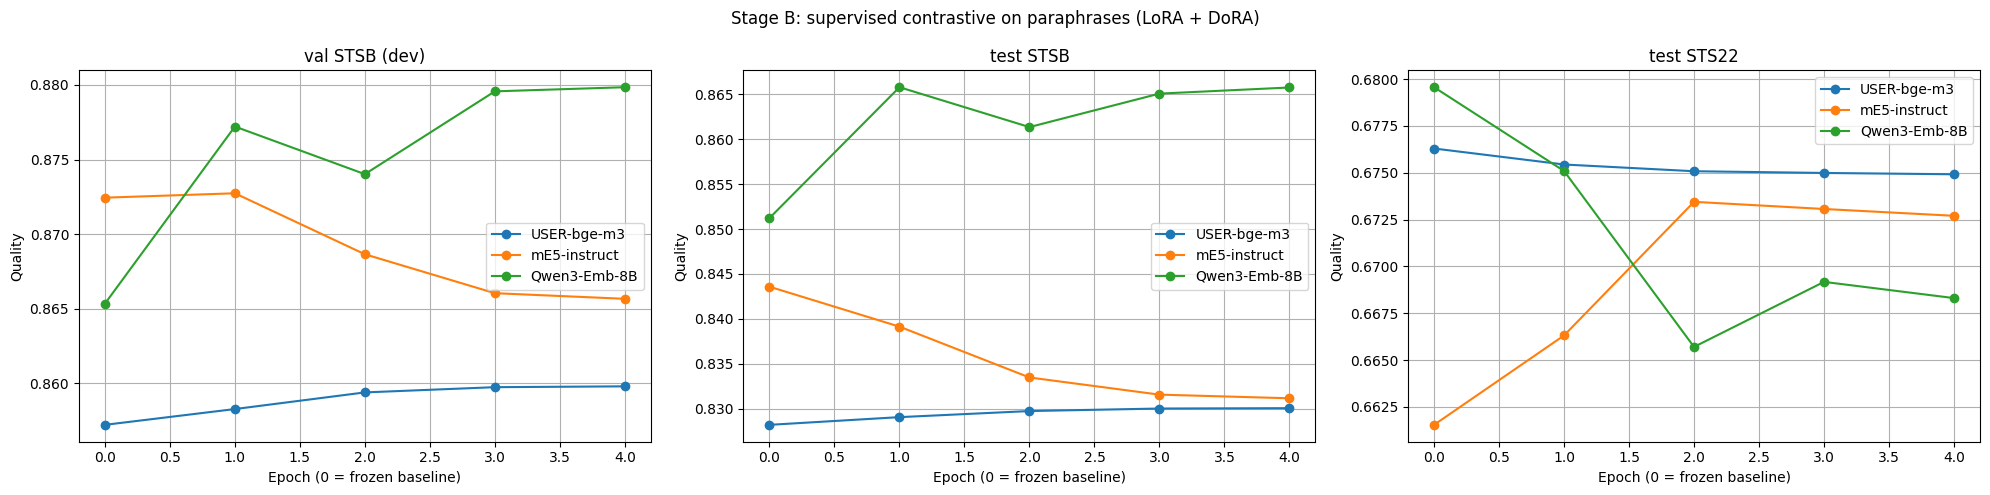

In [ ]:
# ----- Графики обучения (одна линия на модель, эпоха 0 = baseline frozen) -----
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for ax, key, title in zip(axes, ["val_stsb", "test_stsb", "test_sts22"],
                           ["val STSB (dev)", "test STSB", "test STS22"]):
    for name, hist in HISTORIES.items():
        eps = [r["epoch"] for r in hist]
        vals = [r[key] for r in hist]
        ax.plot(eps, vals, marker='o', label=name)
    ax.set_title(title); ax.set_xlabel("Epoch (0 = frozen baseline)")
    ax.set_ylabel("Quality"); ax.legend(); ax.grid(True)
plt.suptitle("Stage B: supervised contrastive on paraphrases (LoRA + DoRA)")
plt.tight_layout(); plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Настройка стилей
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 11
})

# Цвета и маркеры для моделей
MODEL_COLORS = {
    'USER-bge-m3': 'blue',
    'mE5-instruct': 'tab:red',
    'Qwen3-Emb-8B': 'darkgreen'
}

MODEL_MARKERS = {
    'USER-bge-m3': 'o',
    'mE5-instruct': 's',
    'Qwen3-Emb-8B': '^'
}

def plot_combined_val_losses(histories_dict, filename="stageB_losses.png"):
    models = list(histories_dict.keys())
    fig, axes = plt.subplots(len(models), 1, figsize=(9, 4 * len(models)))

    # Если модель одна, axes не будет списком
    if len(models) == 1:
        axes = [axes]

    for ax, model_name in zip(axes, models):
        hist = histories_dict[model_name]
        if not hist: continue

        epochs = [r['epoch'] for r in hist]
        values = [r['val_stsb'] for r in hist]

        ax.plot(
            epochs, values,
            label=f"{model_name} (Stage B)",
            color=MODEL_COLORS.get(model_name, 'black'),
            marker=MODEL_MARKERS.get(model_name, 'o'),
            linewidth=1.5,
            markersize=7
        )

        ax.set_title(f"{model_name}: Качество на валидации STSB", pad=10)
        ax.set_xlabel("Эпохи (0 = baseline)")
        ax.set_ylabel("Целевая метрика (Pearson+Spearman)/2")
        ax.grid(True, linestyle='-', alpha=0.3)
        ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='black')

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    print(f"Saved: {filename}")
    plt.show()

# Генерация графиков на основе накопленной истории
if 'HISTORIES' in globals() and HISTORIES:
    plot_combined_val_losses(HISTORIES, "stageB_val_stsb.png")
else:
    print("История обучения (HISTORIES) не найдена. Сначала запустите обучение.")

In [ ]:
# ----- Сводная таблица baseline vs Stage-B -----
rows = []
for name, r in RESULTS.items():
    rows.append({
        "model": name, "stage": "baseline (frozen)", "best_epoch": 0,
        "val_stsb":   r["baseline"]["val_stsb"],
        "test_stsb":  r["baseline"]["test_stsb"],
        "test_sts22": r["baseline"]["test_sts22"],
    })
    rows.append({
        "model": name, "stage": f"Stage-B (best ep={r['best_epoch']})",
        "best_epoch": r["best_epoch"],
        "val_stsb":   r["end"]["val_stsb"],
        "test_stsb":  r["end"]["test_stsb"],
        "test_sts22": r["end"]["test_sts22"],
        "Δ_val":      r["delta_val"],
        "Δ_test":     r["delta_test"],
        "Δ_sts22":    r["delta_sts22"],
        "ckpt":       CKPT_PATHS.get(name, "—"),
    })

df = pd.DataFrame(rows)
df["test_mean"] = (df["test_stsb"] + df["test_sts22"]) / 2
df_sorted = df.sort_values(["model", "best_epoch"]).reset_index(drop=True)
print("=== Stage B результаты ===")
df_sorted


=== Stage B результаты ===


,model,stage,best_epoch,val_stsb,test_stsb,test_sts22,Δ_val,Δ_test,Δ_sts22,ckpt,test_mean
0,Qwen3-Emb-8B,baseline (frozen),0,0.865456,0.851154,0.680027,NaN,NaN,NaN,NaN,0.765590
1,Qwen3-Emb-8B,Stage-B (best ep=4),4,0.879848,0.865743,0.668311,0.014391,0.014589,-0.011716,./checkpoints_stageB/Qwen3-Emb-8B__stageB.pt,0.767027
2,USER-bge-m3,baseline (frozen),0,0.857217,0.828224,0.676297,NaN,NaN,NaN,NaN,0.752260
3,USER-bge-m3,Stage-B (best ep=3),3,0.859744,0.830033,0.674992,0.002527,0.001809,-0.001305,./checkpoints_stageB/USER-bge-m3__stageB.pt,0.752512
4,mE5-instruct,baseline (frozen),0,0.872453,0.843576,0.661550,NaN,NaN,NaN,NaN,0.752563
5,mE5-instruct,Stage-B (best ep=1),1,0.872739,0.839141,0.666316,0.000287,-0.004435,0.004766,./checkpoints_stageB/mE5-instruct__stageB.pt,0.752728


In [ ]:
# ----- Финальная сводка: чекпойнты для Stage C -----
print("=" * 70)
print("ЧЕКПОЙНТЫ STAGE B (точки входа для Stage C):")
print("=" * 70)
for name in MODEL_SPECS:
    if name in CKPT_PATHS:
        r = RESULTS[name]
        improved = r["delta_val"] > 1e-4
        icon = "✓" if improved else "≈"
        print(f"  {icon} {name:<18} ckpt = {CKPT_PATHS[name]}")
        print(f"     val:   {r['baseline']['val_stsb']:.4f}  ->  {r['end']['val_stsb']:.4f}  ({r['delta_val']:+.4f})")
        print(f"     test:  {r['baseline']['test_stsb']:.4f}  ->  {r['end']['test_stsb']:.4f}  ({r['delta_test']:+.4f})")
        print(f"     sts22: {r['baseline']['test_sts22']:.4f}  ->  {r['end']['test_sts22']:.4f}  ({r['delta_sts22']:+.4f})")
    else:
        print(f"  ✗ {name}: training failed, no checkpoint")

print()
print("=" * 70)
print("ДЛЯ STAGE C:")
print("=" * 70)
print("Загрузить чекпойнты в Stage-C ноутбуке через тот же restore():")
print()
print("  m = STSEncoder(MODEL_SPECS['<name>'], mode='lora', use_dora=USE_DORA).to(device)")
print("  blob = torch.load('./checkpoints_stageB/<name>__stageB.pt', map_location='cpu')")
print("  restore(m, blob['state_dict'])")
print("  # дальше — обычный Stage-C train_stage_c(m, ...)")


ЧЕКПОЙНТЫ STAGE B (точки входа для Stage C):
  ✓ USER-bge-m3        ckpt = ./checkpoints_stageB/USER-bge-m3__stageB.pt
     val:   0.8572  ->  0.8597  (+0.0025)
     test:  0.8282  ->  0.8300  (+0.0018)
     sts22: 0.6763  ->  0.6750  (-0.0013)
  ✓ mE5-instruct       ckpt = ./checkpoints_stageB/mE5-instruct__stageB.pt
     val:   0.8725  ->  0.8727  (+0.0003)
     test:  0.8436  ->  0.8391  (-0.0044)
     sts22: 0.6615  ->  0.6663  (+0.0048)
  ✓ Qwen3-Emb-8B       ckpt = ./checkpoints_stageB/Qwen3-Emb-8B__stageB.pt
     val:   0.8655  ->  0.8798  (+0.0144)
     test:  0.8512  ->  0.8657  (+0.0146)
     sts22: 0.6800  ->  0.6683  (-0.0117)

ДЛЯ STAGE C:
Загрузить чекпойнты в Stage-C ноутбуке через тот же restore():

  m = STSEncoder(MODEL_SPECS['<name>'], mode='lora', use_dora=USE_DORA).to(device)
  blob = torch.load('./checkpoints_stageB/<name>__stageB.pt', map_location='cpu')
  restore(m, blob['state_dict'])
  # дальше — обычный Stage-C train_stage_c(m, ...)
